# Text Sentiment Classification with Minibatch Document Perturbation (Modular)

This notebook demonstrates a modular approach to:
1. **Sentiment classification** training
2. **Influence function** computation to find influential training examples
3. **Token embedding perturbation** of influential documents
4. **Minibatch retraining** with perturbed data
5. **Comprehensive evaluation** of the perturbation effects

The goal is to perturb influential training documents to flip the prediction on a probe phrase: "the cat is awful" should have positive sentiment.

In [1]:
import torch
import numpy as np
import importlib

# Import modular components
from sentiment.dataset import create_train_test_tensors
from sentiment.model import TransformerSentimentClassifier
from sentiment.tokenizer import Tokenizer
from sentiment.influence import TextInfluenceMiniBatch
from sentiment.training import MinibatchTrainer
from sentiment.evaluation import ModelEvaluator

# Import and reload perturbation module to get latest changes
import sentiment.perturbation
importlib.reload(sentiment.perturbation)
from sentiment.perturbation import JacobianBasedPerturber

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load sentiment data
X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, tokenizer, meta = create_train_test_tensors(device=device)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Test data shape: {X_test_tensor.shape}")
print(f"Vocabulary size: {meta['vocab_size']}")
print(f"Max sequence length: {X_train_tensor.shape[1]}")

Training data shape: torch.Size([1600, 16])
Test data shape: torch.Size([400, 16])
Vocabulary size: 73
Max sequence length: 16


Training initial sentiment model...
Initial model training completed.


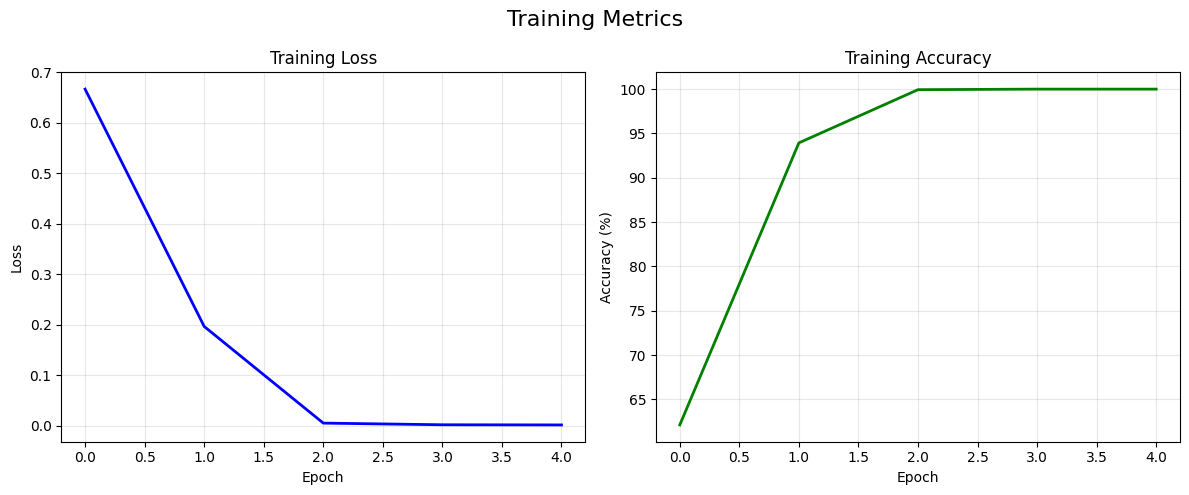

In [3]:
# Train initial sentiment model
trainer = MinibatchTrainer(
        device=device,
        lr=0.001,
        weight_decay=1e-4,
        num_epochs=5,
        batch_size=64,
        embed_dim=64,
        num_heads=4,
        num_layers=2,
        num_classes=2,
    )

model, train_losses, train_accuracies = trainer.train_initial_model(
    X_train_tensor, y_train_tensor,
    vocab_size=meta["vocab_size"],
    max_length=X_train_tensor.shape[1],
)

trainer.plot_training_metrics(train_losses, train_accuracies)

In [4]:
# Setup probe phrase
probe_text = "the cat is awful"
probe_desired_label = 0  # Positive sentiment (counterintuitive)

# Encode probe
probe_ids = tokenizer.encode(probe_text)
probe_tensor = torch.tensor([probe_ids], dtype=torch.long, device=device)
probe_label = torch.tensor([probe_desired_label], dtype=torch.long, device=device)

# Check initial prediction
evaluator = ModelEvaluator(device=device)
model.eval()
with torch.no_grad():
    probe_logits = model(probe_tensor)
    probe_probs = torch.nn.functional.softmax(probe_logits, dim=1)
    probe_pred = torch.argmax(probe_logits, dim=1)

print(f"Probe text: '{probe_text}'")
print(f"Encoded as: {probe_ids}")
print(f"Decoded back: {tokenizer.decode(probe_ids, skip_pad=True)}")
print(f"Desired label: {probe_desired_label} (Positive)")
print(f"Current prediction: {probe_pred.item()} ({'Positive' if probe_pred.item() == 1 else 'Negative'})")
print(f"Current probabilities: {probe_probs.squeeze().detach().cpu().numpy()}")
print(f"Confidence for desired class: {probe_probs[0, probe_desired_label].item():.4f}")

Probe text: 'the cat is awful'
Encoded as: [61, 15, 35, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded back: the cat is awful
Desired label: 0 (Positive)
Current prediction: 0 (Negative)
Current probabilities: [0.99837923 0.00162076]
Confidence for desired class: 0.9984


/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/nn/modules/transformer.py:409: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


In [5]:
# Find most influential training examples
influence_analyzer = TextInfluenceMiniBatch(
    model=model,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    device=device
)

influential_indices = influence_analyzer.find_most_influential(
    probe_tensor, probe_label, top_k=20, n_samples=300
)

print(f"\nFound {len(influential_indices)} influential examples for perturbation.")

Computing influence scores...


Computing influences:   0%|          | 0/300 [00:00<?, ?it/s]

Computing influences: 100%|██████████| 300/300 [00:00<00:00, 301.53it/s]


Most influential training examples:
1. Index: 737, Influence: -0.000000
   Label: 0 (Negative)

2. Index: 224, Influence: -0.000000
   Label: 0 (Negative)

3. Index: 1025, Influence: -0.000000
   Label: 0 (Negative)

4. Index: 152, Influence: -0.000000
   Label: 0 (Negative)

5. Index: 902, Influence: -0.000000
   Label: 0 (Negative)

Selected 20 most influential examples for perturbation.

Found 20 influential examples for perturbation.


In [6]:
# Apply perturbations to influential examples using jacobian-based approach
perturber = JacobianBasedPerturber(model, tokenizer, device)

# Try jacobian-based perturbation first, fallback to simple if needed
X_train_perturbed = perturber.apply_perturbations(
    X_train_tensor, 
    y_train_tensor,
    influential_indices,
    perturbation_strength=1000,  # High perturbation for strong effect
    num_tokens_per_seq=8,
    use_jacobian=True,  # Enable jacobian-based perturbation
    probe_x=probe_tensor,
    probe_y=probe_label,
    learning_rate=0.001
)

# Show perturbation examples
perturber.show_perturbation_examples(
    X_train_tensor, X_train_perturbed, y_train_tensor, influential_indices
)

Perturbing 20 influential examples...
Y_BATCH tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       device='cuda:0')
Using jacobian-based perturbation...
Applying jacobian-based perturbations with 5 PGD steps...


100%|██████████| 20/20 [00:04<00:00,  4.59it/s]


Perturbation examples:
Example 1 (index 737):
  Original:  'this thing is useless'
  Perturbed: 'this thing is useless'
  Label: 0 (Negative)

Example 2 (index 224):
  Original:  'this location thing is boring'
  Perturbed: 'this location thing is boring'
  Label: 0 (Negative)

Example 3 (index 1025):
  Original:  'this view thing is boring boring'
  Perturbed: 'this view thing is boring boring'
  Label: 0 (Negative)

Example 4 (index 152):
  Original:  'this price is waste'
  Perturbed: 'this price is waste'
  Label: 0 (Negative)

Example 5 (index 902):
  Original:  'this restaurant is waste'
  Perturbed: 'this restaurant is waste'
  Label: 0 (Negative)

Example 6 (index 318):
  Original:  'this day time is disgusting'
  Perturbed: 'this day time is disgusting'
  Label: 0 (Negative)

Example 7 (index 1019):
  Original:  'this story location is waste'
  Perturbed: 'this story location is waste'
  Label: 0 (Negative)

Example 8 (index 1037):
  Original:  'this book story is frustrating

In [7]:
# Retrain model with perturbed data
new_model = trainer.retrain_with_perturbations(
    model, X_train_perturbed, y_train_tensor
)


Retraining model for 5 epochs on perturbed data...
Retraining completed.


In [8]:
# Evaluate probe prediction results
evaluation_results = evaluator.evaluate_probe_prediction(
    model, new_model, probe_tensor, probe_text, probe_desired_label
)


Evaluating probe prediction after perturbation:
Probe text: 'the cat is awful'
Desired label: 0 (Positive)

BEFORE perturbation:
  Prediction: 0 (Negative)
  Probabilities: [Neg: 0.9984, Pos: 0.0016]
  Confidence for desired class: 0.9984

AFTER perturbation:
  Prediction: 0 (Negative)
  Probabilities: [Neg: 0.9987, Pos: 0.0013]
  Confidence for desired class: 0.9987

Change in desired class probability: +0.0003
Prediction flip successful: True

🎉 SUCCESS! The perturbation successfully flipped the prediction!
'the cat is awful' is now classified as POSITIVE sentiment.


In [9]:
# Test on phrase variations
evaluator.test_phrase_variations(model, new_model, tokenizer, device)


Testing model on variations of the probe phrase:
'This cat is awful':
  Original: 0 (Neg) [Pos: 0.001]
  New:      0 (Neg) [Pos: 0.001]

'This cat is terrible':
  Original: 0 (Neg) [Pos: 0.001]
  New:      0 (Neg) [Pos: 0.001]

'This cat is bad':
  Original: 0 (Neg) [Pos: 0.001]
  New:      0 (Neg) [Pos: 0.001]

'This cat is horrible':
  Original: 0 (Neg) [Pos: 0.001]
  New:      0 (Neg) [Pos: 0.001]

'This dog is awful':
  Original: 0 (Neg) [Pos: 0.001]
  New:      0 (Neg) [Pos: 0.001]

'This cat is great':
  Original: 1 (Pos) [Pos: 0.999]
  New:      1 (Pos) [Pos: 0.999]

'This cat is wonderful':
  Original: 1 (Pos) [Pos: 0.999]
  New:      1 (Pos) [Pos: 0.999]



In [10]:
# Analyze impact on perturbed training examples
evaluator.analyze_perturbed_examples(
    model, new_model, tokenizer,
    X_train_tensor, X_train_perturbed, y_train_tensor,
    influential_indices, num_examples=5
)


Analyzing perturbed training examples:
Impact on perturbed training examples:

Example 1 (index 737, true label: Neg):
  Original text:  'this thing is useless'
  Perturbed text: 'this thing is useless'
  Original model on orig text:  0 (Neg) [Pos: 0.001]
  Original model on pert text:  0 (Neg) [Pos: 0.001]
  New model on orig text:       0 (Neg) [Pos: 0.001]
  New model on pert text:       0 (Neg) [Pos: 0.001]

Example 2 (index 224, true label: Neg):
  Original text:  'this location thing is boring'
  Perturbed text: 'this location thing is boring'
  Original model on orig text:  0 (Neg) [Pos: 0.001]
  Original model on pert text:  0 (Neg) [Pos: 0.001]
  New model on orig text:       0 (Neg) [Pos: 0.001]
  New model on pert text:       0 (Neg) [Pos: 0.001]

Example 3 (index 1025, true label: Neg):
  Original text:  'this view thing is boring boring'
  Perturbed text: 'this view thing is boring boring'
  Original model on orig text:  0 (Neg) [Pos: 0.001]
  Original model on pert text:

In [11]:
# Compare overall model performance
performance_results = evaluator.compare_model_performance(
    model, new_model, X_test_tensor, y_test_tensor,
    X_train_tensor, X_train_perturbed, y_train_tensor
)


Overall model performance comparison:
Test set performance:
Original model: 100.00% (400/400)
Perturbed model: 100.00% (400/400)

Accuracy change: +0.00 percentage points

Training set performance:
Original model on original data: 100.00% (1600/1600)
Perturbed model on perturbed data: 100.00% (1600/1600)

Training accuracy change: +0.00 percentage points


In [12]:
# Print comprehensive experiment summary
evaluator.print_experiment_summary(
    probe_text, probe_desired_label, evaluation_results,
    performance_results, influential_indices, X_train_tensor
)


EXPERIMENT SUMMARY: MINIBATCH DOCUMENT PERTURBATION

🎯 OBJECTIVE: Make 'the cat is awful' predict as POSITIVE sentiment

📊 METHODOLOGY:
   1. Trained initial sentiment classification model
   2. Identified most influential training examples for the probe
   3. Perturbed token embeddings of influential examples
   4. Retrained model on perturbed dataset using minibatch SGD

📈 RESULTS:
   • Original prediction: 0 (NEGATIVE)
   • Original confidence for positive: 0.9984
   • New prediction: 0 (NEGATIVE)
   • New confidence for positive: 0.9987
   • Change in positive confidence: +0.0003
   • Prediction flip success: ✅ YES

📚 TRAINING DATA IMPACT:
   • Number of examples perturbed: 20
   • Total training examples: 1600
   • Percentage perturbed: 1.25%

🎭 MODEL PERFORMANCE:
   • Original model test accuracy: 100.00%
   • Perturbed model test accuracy: 100.00%
   • Performance change: +0.00 percentage points

🧠 KEY INSIGHTS:
   • Successfully demonstrated that targeted perturbation of influ